1. **Machine Learning Stage**

In this stage, machine learning methods are applied to predict used-car prices using the cleaned dataset. In line with the project proposal, the main goal is to compare a baseline model using structural vehicle characteristics with an extended model that additionally includes cosmetic information, especially color.

Two model families are used. First, Linear Regression is employed as a benchmark model. Second, a Random Forest Regressor is used as the main machine learning method. For both model families, a baseline feature set and an extended feature set are trained and evaluated using the same train-test split. Model performance is compared using MAE, RMSE, and R².

The key question in this stage is whether adding color improves predictive performance in a meaningful way. If the improvement remains small, this would support the earlier statistical findings that cosmetic variables have only a limited practical role compared with structural vehicle characteristics.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (9, 6)
pd.set_option("display.max_columns", 200)

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/CAR_DATA.csv")

# Quick check
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50755, 16)


,id,marka,seri,model,yil,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,kimden,fiyat
0,1,Lexus,ES,300h Business Plus,2023.0,43000.0,Otomatik,Benzin,Sedan,Siyah,2250.0,213.0,1.0,1.0,Galeriden,4950000.0
1,2,Lexus,GS,200t Luxury,2023.0,25000.0,Otomatik,Benzin,Hatchback/5,Mavi,NaN,213.0,1.0,0.0,Galeriden,1265000.0
2,3,Lexus,LS,500h Exclusive,2021.0,23665.0,Otomatik,Benzin,Sedan,Siyah,3250.0,363.0,0.0,0.0,Galeriden,9000000.0
3,4,Kuba,City,NaN,2024.0,0.0,Otomatik,Elektrik,Hatchback/3,Kahverengi,NaN,50.0,0.0,0.0,Galeriden,279999.0
4,5,Lexus,GS,200t F Sport,2016.0,90500.0,Otomatik,Benzin,Sedan,Beyaz,1900.0,238.0,0.0,0.0,Galeriden,2745000.0


In [3]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

rename_map = {
    "marka": "brand",
    "seri": "series",
    "model": "model",
    "yil": "year",
    "kilometre": "km",
    "vites_tipi": "transmission",
    "yakit_tipi": "fuel",
    "kasa_tipi": "body_type",
    "renk": "color",
    "fiyat": "price",
    "motor_hacmi": "engine_volume",
    "motor_gucu": "engine_power",
    "degisen_sayisi": "changed_parts",
    "boyali_sayisi": "painted_parts",
    "kimden": "seller_type"
}

df = df.rename(columns=rename_map)

# Numeric columns
numeric_cols = [
    "price", "km", "year", "engine_volume",
    "engine_power", "changed_parts", "painted_parts"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical cleanup
cat_cols = [
    "brand", "series", "model", "transmission",
    "fuel", "body_type", "color", "seller_type"
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

# Remove duplicates
df = df.drop_duplicates()

# Keep only rows with main variables
required_cols = [
    "price", "brand", "model", "year", "km",
    "fuel", "transmission", "body_type", "color"
]
df = df.dropna(subset=required_cols)

# Basic validity filters
df = df[(df["price"] > 0) & (df["km"] >= 0)]
df = df[(df["year"] >= 1990) & (df["year"] <= 2026)]

# Outlier trimming
low_p, high_p = df["price"].quantile([0.01, 0.99])
df = df[(df["price"] >= low_p) & (df["price"] <= high_p)]

low_km, high_km = df["km"].quantile([0.01, 0.99])
df = df[(df["km"] >= low_km) & (df["km"] <= high_km)]

# Log transforms
df["log_price"] = np.log(df["price"])
df["log_km"] = np.log1p(df["km"])

# Group rare categories
def group_rare_categories(series, min_count=100):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return pd.Series(np.where(series.isin(keep), series, "Other"), index=series.index)

df["color_group"] = group_rare_categories(df["color"], min_count=100)
df["body_group"] = group_rare_categories(df["body_type"], min_count=100)
df["series_group"] = group_rare_categories(df["series"], min_count=100)

print("Cleaned shape:", df.shape)
df[["price", "km", "year", "log_price", "log_km"]].describe()

Cleaned shape: (48062, 21)


,price,km,year,log_price,log_km
count,4.806200e+04,48062.000000,48062.000000,48062.000000,48062.000000
mean,7.832169e+05,190004.156902,2010.584661,13.321949,11.983612
std,6.216546e+05,92583.959922,7.949199,0.703771,0.673769
min,1.180000e+05,8700.000000,1990.000000,11.678440,9.071193
25%,3.700000e+05,120000.000000,2005.000000,12.821258,11.695255
50%,6.100000e+05,190000.000000,2012.000000,13.321214,12.154785
75%,9.950000e+05,255000.000000,2016.000000,13.810498,12.449023
max,4.850000e+06,450000.000000,2025.000000,15.394489,13.017005


In [4]:
ml_cols = [
    "price", "log_price", "year", "log_km",
    "brand", "series_group", "fuel",
    "transmission", "body_group", "seller_type", "color_group"
]

df_ml = df[ml_cols].dropna().copy()
print(df_ml.shape)
df_ml.head()

(48062, 11)


,price,log_price,year,log_km,brand,series_group,fuel,transmission,body_group,seller_type,color_group
1,1265000.0,14.050583,2023.0,10.126671,Lexus,Other,Benzin,Otomatik,Hatchback/5,Galeriden,Mavi
4,2745000.0,14.825292,2016.0,11.413116,Lexus,Other,Benzin,Otomatik,Sedan,Galeriden,Beyaz
5,225000.0,12.323856,1996.0,12.345839,Infiniti,Other,LPG & Benzin,Otomatik,Sedan,Sahibinden,Yeşil
6,475000.0,13.071070,1996.0,12.604852,Infiniti,Other,LPG & Benzin,Otomatik,Sedan,Sahibinden,Yeşil
7,1950000.0,14.483340,2016.0,11.918397,Infiniti,Other,Benzin,Otomatik,Sedan,Galeriden,Beyaz


In [5]:
baseline_features = [
    "year", "log_km",
    "brand", "series_group", "fuel",
    "transmission", "body_group", "seller_type"
]

extended_features = baseline_features + ["color_group"]

target = "log_price"

In [6]:
X_base = df_ml[baseline_features]
X_ext = df_ml[extended_features]
y = df_ml[target]

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

X_ext_train, X_ext_test, _, _ = train_test_split(
    X_ext, y, test_size=0.2, random_state=42
)

print(X_base_train.shape, X_base_test.shape)
print(X_ext_train.shape, X_ext_test.shape)

(38449, 8) (9613, 8)
(38449, 9) (9613, 9)


In [7]:
base_cat = ["brand", "series_group", "fuel", "transmission", "body_group", "seller_type"]
base_num = ["year", "log_km"]

ext_cat = base_cat + ["color_group"]
ext_num = base_num

base_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), base_cat),
        ("num", "passthrough", base_num)
    ]
)

ext_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ext_cat),
        ("num", "passthrough", ext_num)
    ]
)

In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    y_test_price = np.exp(y_test)
    pred_price = np.exp(pred_log)

    mae = mean_absolute_error(y_test_price, pred_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
    r2 = r2_score(y_test_price, pred_price)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [9]:
lr_base = Pipeline([
    ("preprocessor", base_preprocessor),
    ("model", LinearRegression())
])

lr_ext = Pipeline([
    ("preprocessor", ext_preprocessor),
    ("model", LinearRegression())
])

results = []

results.append(
    evaluate_model(lr_base, X_base_train, X_base_test, y_train, y_test, "Linear Regression - Baseline")
)

results.append(
    evaluate_model(lr_ext, X_ext_train, X_ext_test, y_train, y_test, "Linear Regression - Extended")
)

In [10]:
rf_base = Pipeline([
    ("preprocessor", base_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=2,
        max_samples=0.7,
        random_state=42,
        n_jobs=-1
    ))
])

rf_ext = Pipeline([
    ("preprocessor", ext_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=2,
        max_samples=0.7,
        random_state=42,
        n_jobs=-1
    ))
])

results.append(
    evaluate_model(rf_base, X_base_train, X_base_test, y_train, y_test, "Random Forest - Baseline")
)

results.append(
    evaluate_model(rf_ext, X_ext_train, X_ext_test, y_train, y_test, "Random Forest - Extended")
)

In [11]:
results_raw = pd.DataFrame(results)
results_pretty = results_raw.copy()

results_pretty["MAE"] = results_pretty["MAE"].map(lambda x: f"{x:,.0f}")
results_pretty["RMSE"] = results_pretty["RMSE"].map(lambda x: f"{x:,.0f}")
results_pretty["R2"] = results_pretty["R2"].map(lambda x: f"{x:.4f}")

print(results_pretty)

                          Model      MAE     RMSE      R2
0  Linear Regression - Baseline  110,410  228,835  0.8625
1  Linear Regression - Extended  110,484  228,551  0.8628
2      Random Forest - Baseline  122,067  257,389  0.8260
3      Random Forest - Extended  129,583  274,703  0.8018


In [12]:
results_raw.to_csv("/content/ml_results.csv", index=False)
results_raw

,Model,MAE,RMSE,R2
0,Linear Regression - Baseline,110409.670280,228834.959261,0.862483
1,Linear Regression - Extended,110484.168992,228551.397811,0.862823
2,Random Forest - Baseline,122067.091285,257389.299493,0.826022
3,Random Forest - Extended,129582.562961,274702.563484,0.801830


In [13]:
rf_ext.fit(X_ext_train, y_train)

feature_names = rf_ext.named_steps["preprocessor"].get_feature_names_out()
importances = rf_ext.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

,feature,importance
199,num__year,0.256489
161,cat__transmission_Düz,0.161494
200,num__log_km,0.093643
162,cat__transmission_Otomatik,0.073126
160,cat__fuel_LPG & Benzin,0.052593
53,cat__brand_Tofaş,0.038127
156,cat__fuel_Benzin,0.034018
34,cat__brand_Mercedes - Benz,0.025721
3,cat__brand_BMW,0.016928
173,cat__seller_type_Galeriden,0.015510


In [14]:
def map_feature_family(feature_name):
    if "brand" in feature_name:
        return "brand"
    elif "series_group" in feature_name:
        return "series_group"
    elif "fuel" in feature_name:
        return "fuel"
    elif "transmission" in feature_name:
        return "transmission"
    elif "body_group" in feature_name:
        return "body_group"
    elif "seller_type" in feature_name:
        return "seller_type"
    elif "color_group" in feature_name:
        return "color_group"
    elif "year" in feature_name:
        return "year"
    elif "log_km" in feature_name:
        return "log_km"
    else:
        return "other"

fi["family"] = fi["feature"].apply(map_feature_family)

agg_fi = (
    fi.groupby("family", as_index=False)["importance"]
      .sum()
      .sort_values("importance", ascending=False)
)

agg_fi

,family,importance
8,year,0.256489
7,transmission,0.247866
1,brand,0.140147
6,series_group,0.097116
3,fuel,0.095984
4,log_km,0.093643
5,seller_type,0.028356
0,body_group,0.022661
2,color_group,0.017739


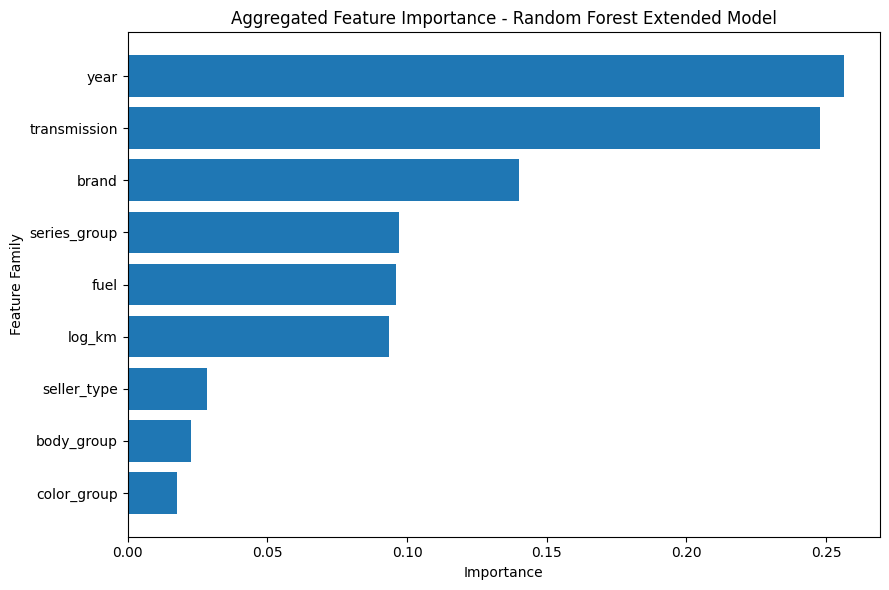

In [15]:
plot_df = agg_fi.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["family"], plot_df["importance"])
plt.title("Aggregated Feature Importance - Random Forest Extended Model")
plt.xlabel("Importance")
plt.ylabel("Feature Family")
plt.tight_layout()
plt.show()

In [16]:
example = X_ext_test.iloc[[0]].copy()

color_options = df_ml["color_group"].value_counts().head(8).index.tolist()

counterfactual_results = []

for c in color_options:
    temp = example.copy()
    temp["color_group"] = c

    pred_log = rf_ext.predict(temp)[0]
    pred_price = np.exp(pred_log)

    counterfactual_results.append({
        "color_group": c,
        "predicted_price": pred_price
    })

cf_df = pd.DataFrame(counterfactual_results).sort_values("predicted_price", ascending=False)
cf_df

,color_group,predicted_price
2,Siyah,379663.604470
6,Füme,373261.168124
4,Gri (Gümüş),372730.559165
7,Lacivert,372423.363270
5,Mavi,368971.842660
1,Gri,368763.327360
3,Kırmızı,368587.265824
0,Beyaz,363925.766148


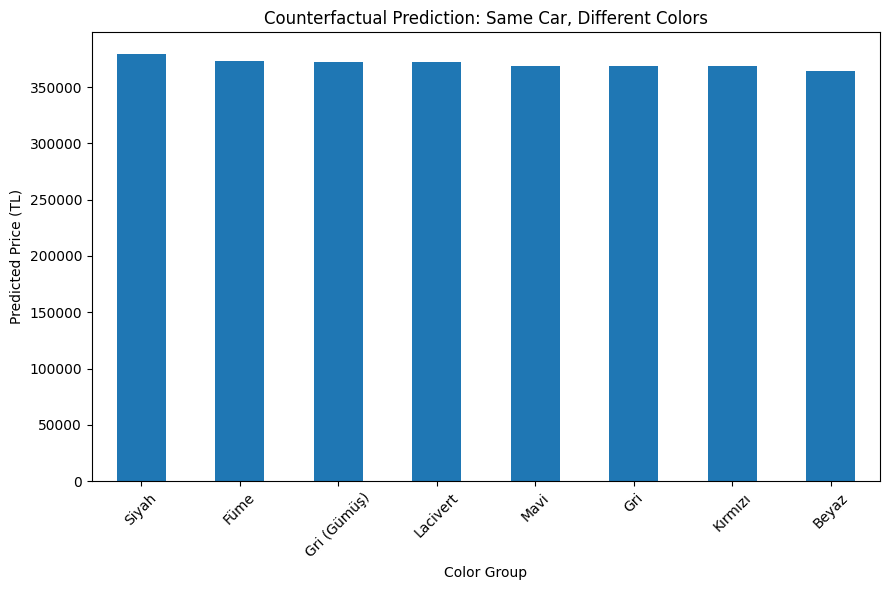

In [17]:
cf_df.plot(kind="bar", x="color_group", y="predicted_price", legend=False, rot=45)
plt.title("Counterfactual Prediction: Same Car, Different Colors")
plt.xlabel("Color Group")
plt.ylabel("Predicted Price (TL)")
plt.tight_layout()
plt.show()

10. **Interpretation of the Machine Learning Results**

The machine learning results are expected to show that structural variables explain most of the predictive performance in used-car price estimation. If the extended models including color perform only slightly better than the baseline models, this would support the earlier hypothesis-testing results. In that case, color would provide some additional information, but its practical contribution would remain limited compared with structural variables such as brand, series, year, mileage, fuel type, transmission, and body type.

The Random Forest feature-importance analysis is also useful for checking whether color appears among the major determinants of prediction. If color-related features remain relatively weak compared with year, mileage, and brand-related features, this would further support the project’s main claim that cosmetic attributes have only a small marginal role in price formation.